# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [17]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [18]:
df=pd.read_csv("Aviation_Safety_Cleaned_1983_2023.csv")

/tmp/ipykernel_19797/3379532275.py:1: DtypeWarning: Columns (0: Latitude, 1: Longitude, 2: Broad.phase.of.flight) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("Aviation_Safety_Cleaned_1983_2023.csv")


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [19]:
#Segment based on client requirements (20 passengers)
# We use 'Total.Occupants' created in the cleaning phase
large_planes = df[df['Total.Occupants'] >= 20].copy()
small_planes = df[(df['Total.Occupants'] < 20) & (df['Total.Occupants'] > 0)].copy()

print(f"Large Aircraft Samples: {len(large_planes)}")
print(f"Small Aircraft Samples: {len(small_planes)}")

Large Aircraft Samples: 1754
Small Aircraft Samples: 51522


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

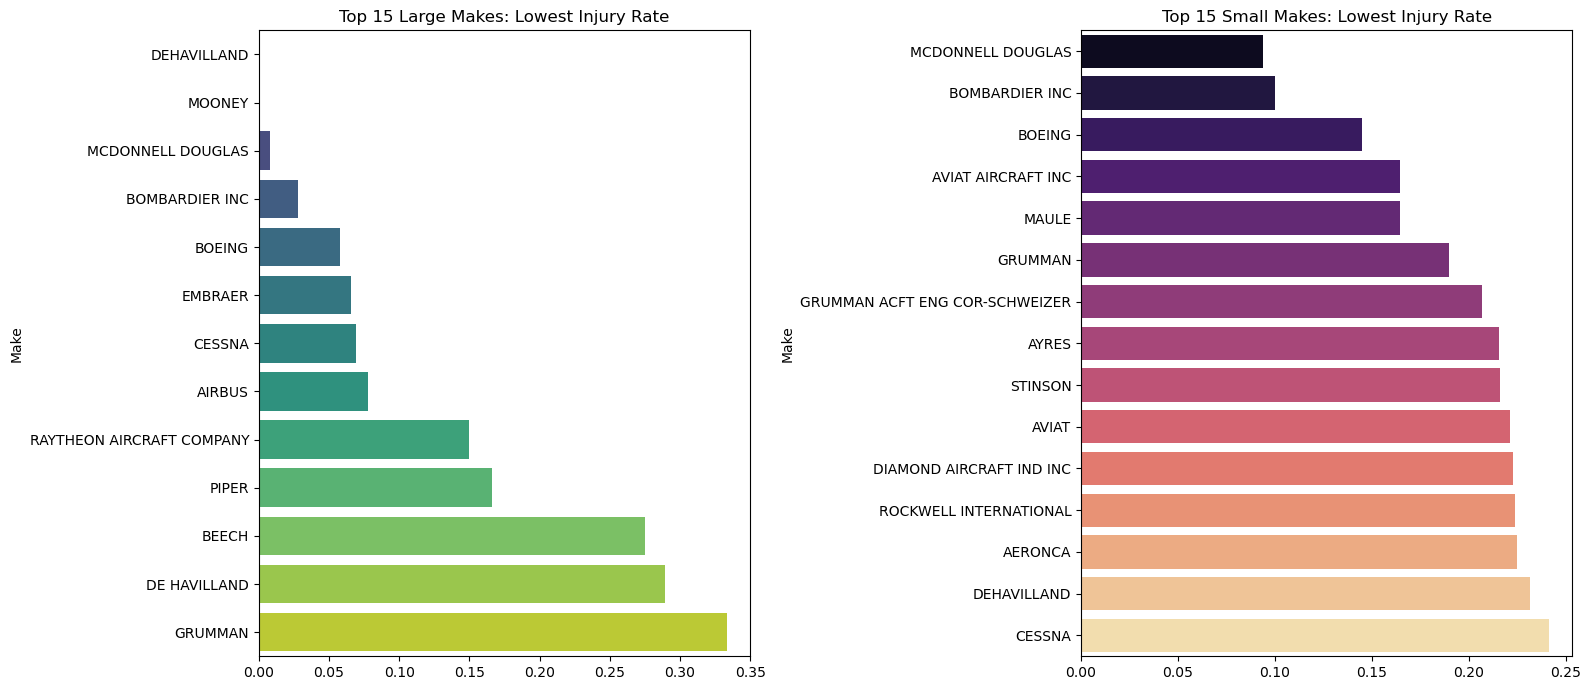

In [20]:
# Top 15 Makes by lowest injury rate
large_make_safety = large_planes.groupby('Make')['Injury.Rate'].mean().sort_values().head(15)
small_make_safety = small_planes.groupby('Make')['Injury.Rate'].mean().sort_values().head(15)

# Plotting side-by-side
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(x=large_make_safety.values, y=large_make_safety.index, ax=ax[0], palette='viridis', hue=large_make_safety.index, legend=False)
ax[0].set_title('Top 15 Large Makes: Lowest Injury Rate')
sns.barplot(x=small_make_safety.values, y=small_make_safety.index, ax=ax[1], palette='magma', hue=small_make_safety.index, legend=False)
ax[1].set_title('Top 15 Small Makes: Lowest Injury Rate')
plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

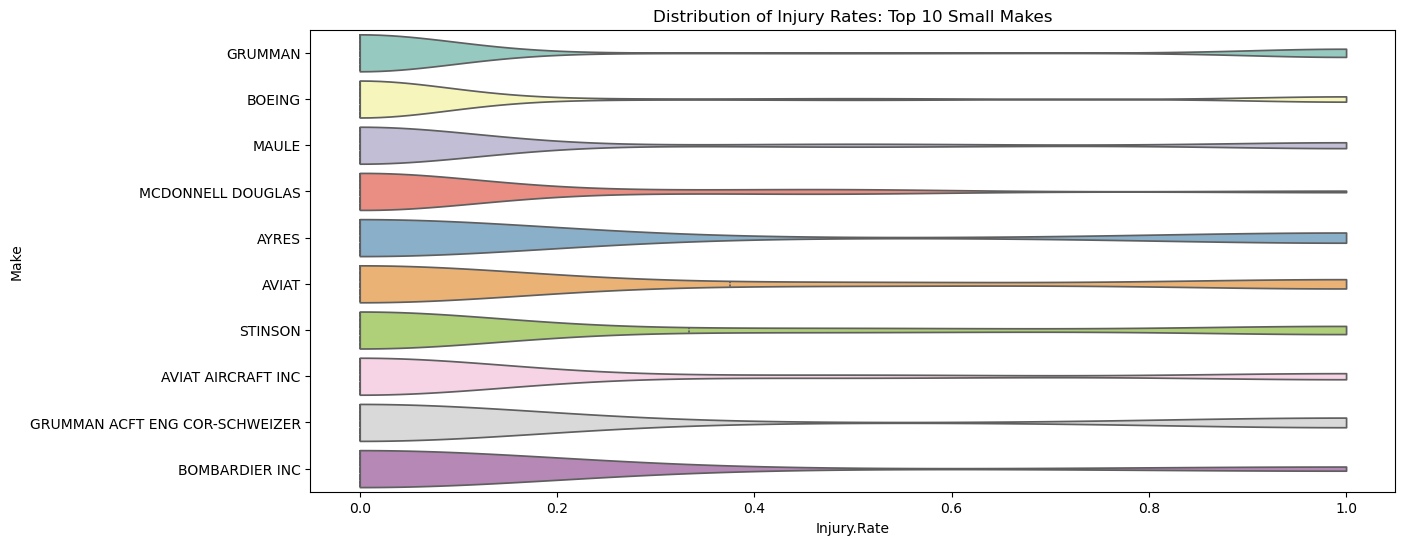

In [22]:
# Violinplot for Small Makes (Top 10)
top_10_small = small_planes.groupby('Make')['Injury.Rate'].mean().nsmallest(10).index
small_top_df = small_planes[small_planes['Make'].isin(top_10_small)]
plt.figure(figsize=(14, 6))
sns.violinplot(data=small_top_df, x='Injury.Rate', y='Make', inner="quart", palette="Set3", hue='Make', legend=False, cut=0)
plt.title('Distribution of Injury Rates: Top 10 Small Makes')
plt.show()



**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

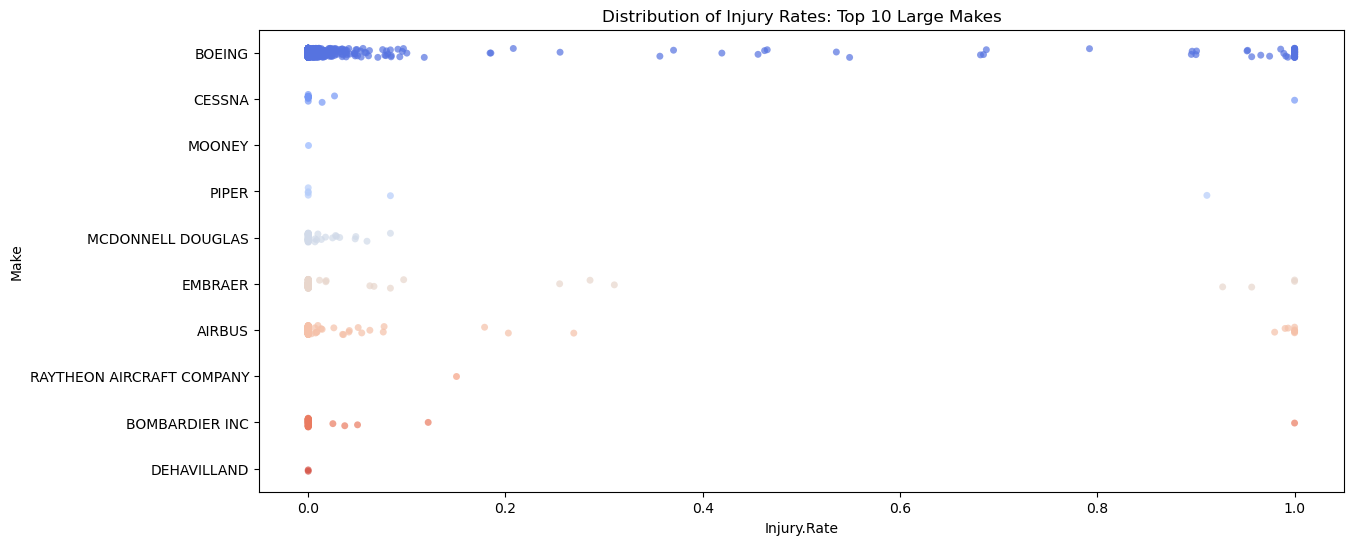

In [23]:
# Plot 3: Strip plot for Large Makes (Top 10)
top_10_large = large_planes.groupby('Make')['Injury.Rate'].mean().nsmallest(10).index
large_top_df = large_planes[large_planes['Make'].isin(top_10_large)]
plt.figure(figsize=(14, 6))
sns.stripplot(data=large_top_df, x='Injury.Rate', y='Make', size=5, alpha=0.7, palette='coolwarm', hue='Make')
plt.title('Distribution of Injury Rates: Top 10 Large Makes')
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [24]:
# Calculating the fraction of accidents resulting in 'is_destroyed'
large_destruction = large_planes.groupby('Make')['is_destroyed'].mean().sort_values().head(15)
small_destruction = small_planes.groupby('Make')['is_destroyed'].mean().sort_values().head(15)

print("Safest Large Makes (Lowest Destruction Rate):")
print(large_destruction)

Safest Large Makes (Lowest Destruction Rate):
Make
DEHAVILLAND                  0.000000
MOONEY                       0.000000
RAYTHEON AIRCRAFT COMPANY    0.000000
BOMBARDIER INC               0.022727
EMBRAER                      0.051282
BOEING                       0.057471
MCDONNELL DOUGLAS            0.075472
AIRBUS                       0.076336
CESSNA                       0.133333
DE HAVILLAND                 0.250000
PIPER                        0.333333
GRUMMAN                      0.333333
BEECH                        0.400000
Name: is_destroyed, dtype: float64


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

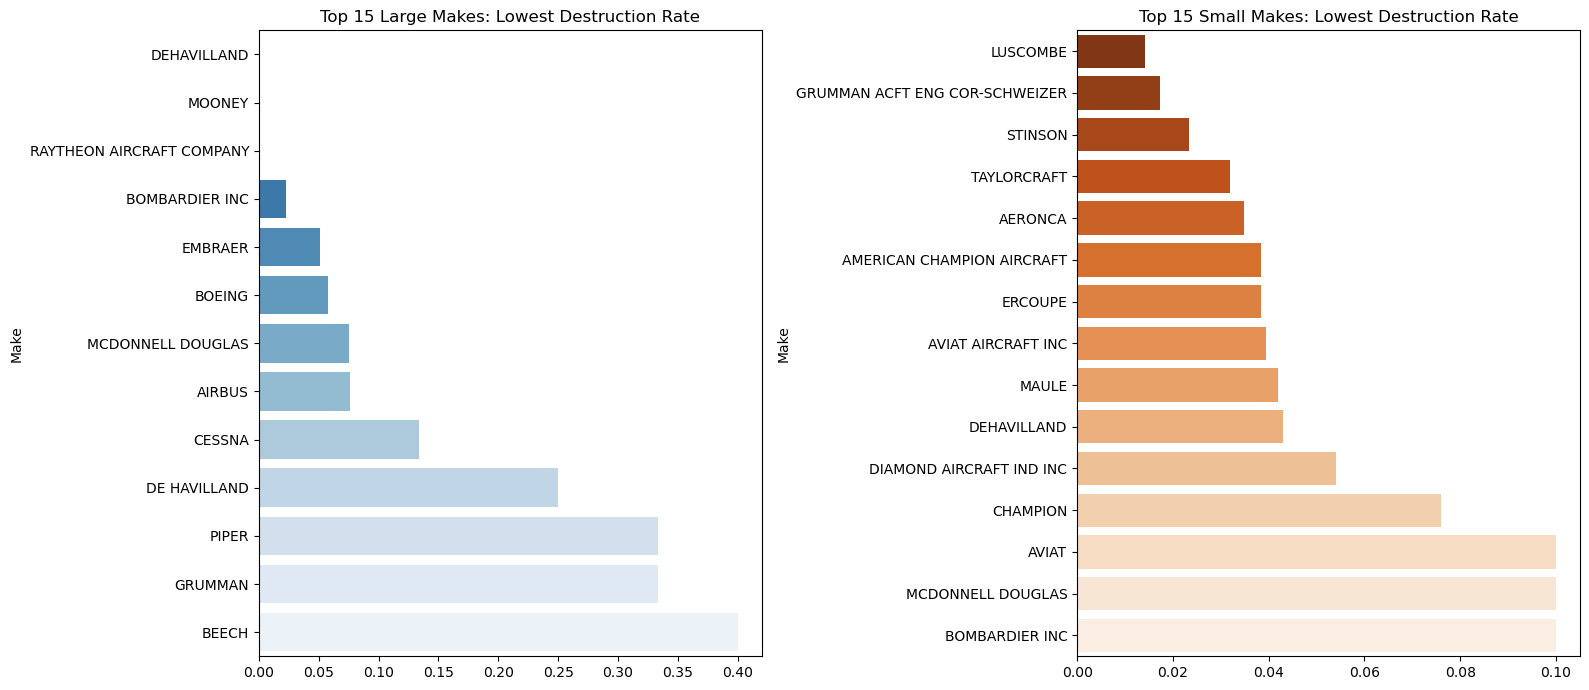

In [25]:
# Plot 4: Destruction Rate
large_destruction = large_planes.groupby('Make')['is_destroyed'].mean().sort_values().head(15)
small_destruction = small_planes.groupby('Make')['is_destroyed'].mean().sort_values().head(15)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(x=large_destruction.values, y=large_destruction.index, ax=ax[0], palette='Blues_r', hue=large_destruction.index)
ax[0].set_title('Top 15 Large Makes: Lowest Destruction Rate')
ax[0].get_legend().remove() if ax[0].get_legend() else None

sns.barplot(x=small_destruction.values, y=small_destruction.index, ax=ax[1], palette='Oranges_r', hue=small_destruction.index)
ax[1].set_title('Top 15 Small Makes: Lowest Destruction Rate')
ax[1].get_legend().remove() if ax[1].get_legend() else None

plt.tight_layout()
plt.show()

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

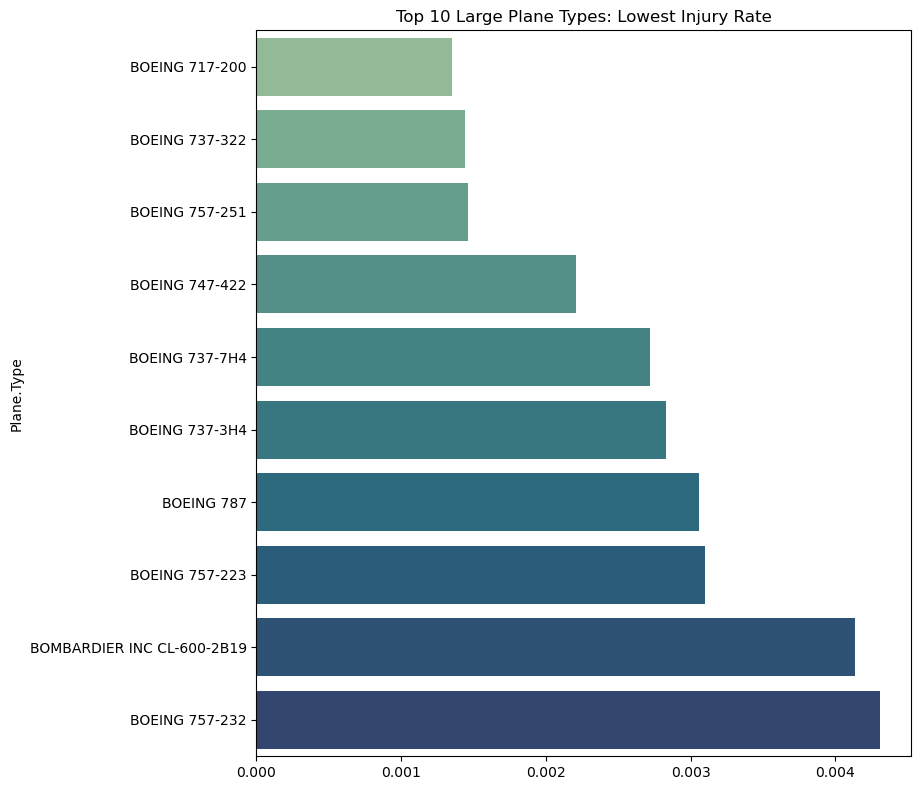

In [29]:
def filter_types(data):
    counts = data['Plane.Type'].value_counts()
    valid_types = counts[counts >= 10].index
    return data[data['Plane.Type'].isin(valid_types)]

large_types = filter_types(large_planes)
small_types = filter_types(small_planes)

top_small_types_plot = small_types.groupby('Plane.Type')['Injury.Rate'].mean().nsmallest(10)
top_large_types_plot = large_types.groupby('Plane.Type')['Injury.Rate'].mean().nsmallest(10)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
sns.barplot(x=top_large_types_plot.values, y=top_large_types_plot.index, palette='crest', hue=top_large_types_plot.index)
plt.title('Top 10 Large Plane Types: Lowest Injury Rate')
plt.tight_layout()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

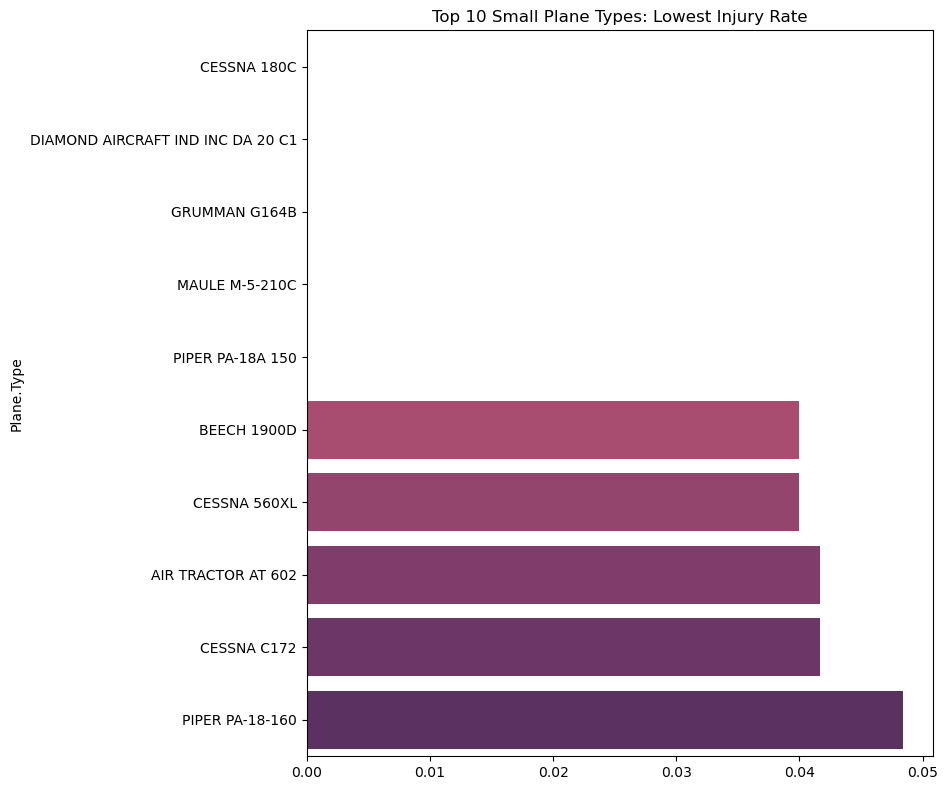

In [30]:
def filter_types(data):
    counts = data['Plane.Type'].value_counts()
    valid_types = counts[counts >= 10].index
    return data[data['Plane.Type'].isin(valid_types)]


small_types = filter_types(small_planes)

top_small_types_plot = small_types.groupby('Plane.Type')['Injury.Rate'].mean().nsmallest(10)
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 2)
sns.barplot(x=top_small_types_plot.values, y=top_small_types_plot.index, palette='flare', hue=top_small_types_plot.index)
plt.title('Top 10 Small Plane Types: Lowest Injury Rate')
plt.tight_layout()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

EDA Complete. All plots saved.

Top 5 Safest Large Makes (Destruction Rate):
Make
DEHAVILLAND                  0.000000
MOONEY                       0.000000
RAYTHEON AIRCRAFT COMPANY    0.000000
BOMBARDIER INC               0.022727
EMBRAER                      0.051282
Name: is_destroyed, dtype: float64

Top 5 Safest Small Makes (Destruction Rate):
Make
LUSCOMBE                          0.014184
GRUMMAN ACFT ENG COR-SCHWEIZER    0.017241
STINSON                           0.023256
TAYLORCRAFT                       0.031915
AERONCA                           0.034826
Name: is_destroyed, dtype: float64


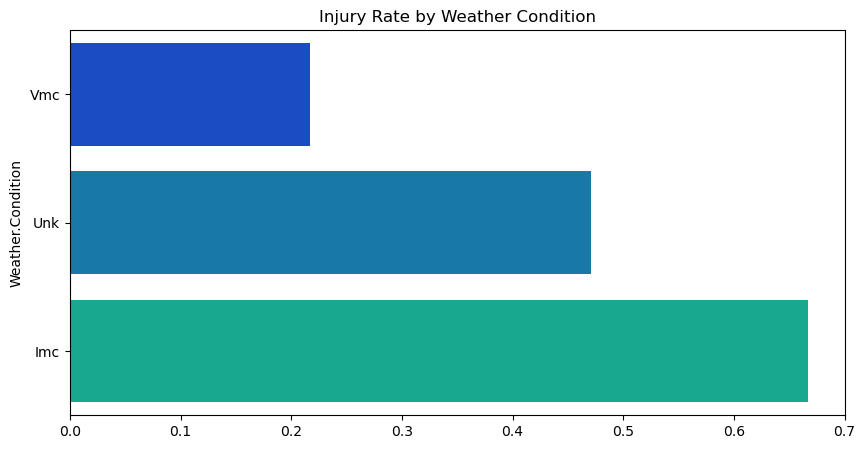

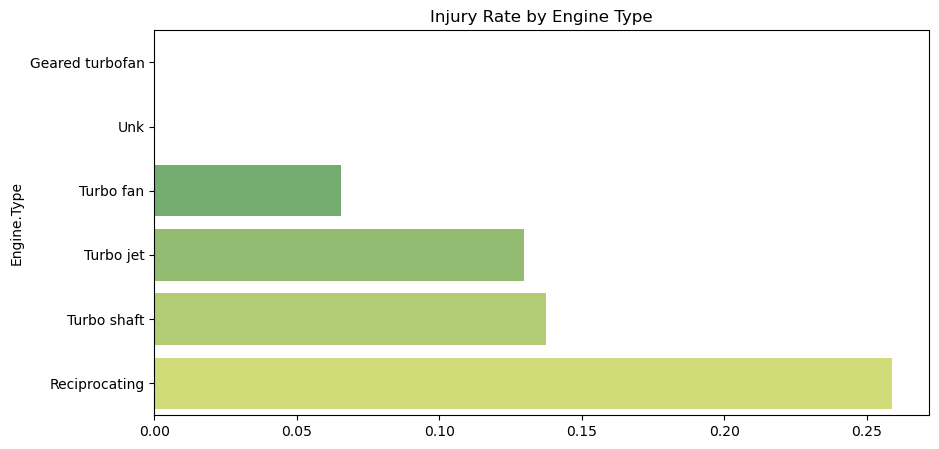

In [27]:
# Weather Condition
weather_stats = df.groupby('Weather.Condition')['Injury.Rate'].mean().sort_values()
plt.figure(figsize=(10, 5))
sns.barplot(x=weather_stats.values, y=weather_stats.index, palette='winter', hue=weather_stats.index)
plt.title('Injury Rate by Weather Condition')
plt.savefig('weather_safety.png')

# Engine Type
engine_stats = df.groupby('Engine.Type')['Injury.Rate'].mean().sort_values().head(6)
plt.figure(figsize=(10, 5))
sns.barplot(x=engine_stats.values, y=engine_stats.index, palette='summer', hue=engine_stats.index)
plt.title('Injury Rate by Engine Type')
plt.savefig('engine_safety.png')

print("EDA Complete. All plots saved.")
print("\nTop 5 Safest Large Makes (Destruction Rate):")
print(large_destruction.head(5))
print("\nTop 5 Safest Small Makes (Destruction Rate):")
print(small_destruction.head(5))